# PACKAGES AND LIBRARIES

In [21]:
# GENERAL
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn scikit-image scipy tensorflow keras xgboost lightgbm catboost opencv-python pillow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from pathlib import Path
import glob

# IMAGE PROCESSING
import cv2
from PIL import Image
import skimage
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
from skimage import io, filters
from scipy.ndimage import convolve

# TENSORFLOW / KERAS (modern way)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras import regularizers

# SKLEARN
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import *

# ML MODELS
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# BOOSTING MODELS
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# WARNINGS
import warnings
warnings.filterwarnings("ignore")

# PATH, LABEL, TRANSFORMATION

#### MAIN PATH

In [22]:
Indian_Sign_Main_Path = Path("C:/PROJECTS/project/backend/dataset/Indian")

#### JPG PATH

In [23]:
Sign_JPG = list(Indian_Sign_Main_Path.glob(r"*/*.jpg"))

#### LABELS

In [24]:
Sign_Labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], Sign_JPG))

#### TO SERIES

In [25]:
Sign_JPG_Series = pd.Series(Sign_JPG, name="JPG").astype(str)
Sign_Labels_Series = pd.Series(Sign_Labels, name="CATEGORY")

#### TO DATAFRAME

In [26]:
Main_Sign_Data = pd.concat([Sign_JPG_Series, Sign_Labels_Series], axis=1)

In [27]:
print(Main_Sign_Data.head(-1))

                                                     JPG CATEGORY
0      C:\PROJECTS\project\backend\dataset\Indian\1\0...        1
1      C:\PROJECTS\project\backend\dataset\Indian\1\1...        1
2      C:\PROJECTS\project\backend\dataset\Indian\1\1...        1
3      C:\PROJECTS\project\backend\dataset\Indian\1\1...        1
4      C:\PROJECTS\project\backend\dataset\Indian\1\1...        1
...                                                  ...      ...
42739  C:\PROJECTS\project\backend\dataset\Indian\Z\9...        Z
42740  C:\PROJECTS\project\backend\dataset\Indian\Z\9...        Z
42741  C:\PROJECTS\project\backend\dataset\Indian\Z\9...        Z
42742  C:\PROJECTS\project\backend\dataset\Indian\Z\9...        Z
42743  C:\PROJECTS\project\backend\dataset\Indian\Z\9...        Z

[42744 rows x 2 columns]


#### TO SHUFFLE

In [28]:
Main_Sign_Data = Main_Sign_Data.sample(frac=1).reset_index(drop=True)

In [29]:
print(Main_Sign_Data.head(-1))

                                                     JPG CATEGORY
0      C:\PROJECTS\project\backend\dataset\Indian\A\3...        A
1      C:\PROJECTS\project\backend\dataset\Indian\K\5...        K
2      C:\PROJECTS\project\backend\dataset\Indian\O\8...        O
3      C:\PROJECTS\project\backend\dataset\Indian\E\6...        E
4      C:\PROJECTS\project\backend\dataset\Indian\T\5...        T
...                                                  ...      ...
42739  C:\PROJECTS\project\backend\dataset\Indian\U\2...        U
42740  C:\PROJECTS\project\backend\dataset\Indian\D\1...        D
42741  C:\PROJECTS\project\backend\dataset\Indian\Q\5...        Q
42742  C:\PROJECTS\project\backend\dataset\Indian\5\4...        5
42743  C:\PROJECTS\project\backend\dataset\Indian\4\3...        4

[42744 rows x 2 columns]


# VISION

#### VISION FUNCTION

In [30]:
def simple_vision(img_path):
    Picking_Img = cv2.cvtColor(cv2.imread(img_path),cv2.COLOR_BGR2RGB)
    
    return Picking_Img

In [31]:
def threshold_vision(img_path):
    Picking_Img = simple_vision(img_path)
    Gray_Img = cv2.cvtColor(Picking_Img,cv2.COLOR_RGB2GRAY)
    _,threshold_Img = cv2.threshold(Gray_Img,90,255,cv2.THRESH_BINARY_INV)
    
    return threshold_Img
    

In [32]:
def canny_vision(img_path):
    Threshold_Img = threshold_vision(img_path)
    Canny_Img = cv2.Canny(Threshold_Img,10,100)
    
    return Canny_Img

In [33]:
def skeleton_morph_vision(img_path):
    Picking_Img = simple_vision(img_path)
    Gray_Img = cv2.cvtColor(Picking_Img,cv2.COLOR_RGB2GRAY)
    _,Threshold_Img = cv2.threshold(Gray_Img,90,255,cv2.THRESH_BINARY_INV)
    
    Array_Img = np.array(Gray_Img > Threshold_Img).astype(int)
    Skeleton_Img = skimage.morphology.skeletonize(Array_Img)
    
    return Skeleton_Img

#### CHECKING

##### EXAMPLE I

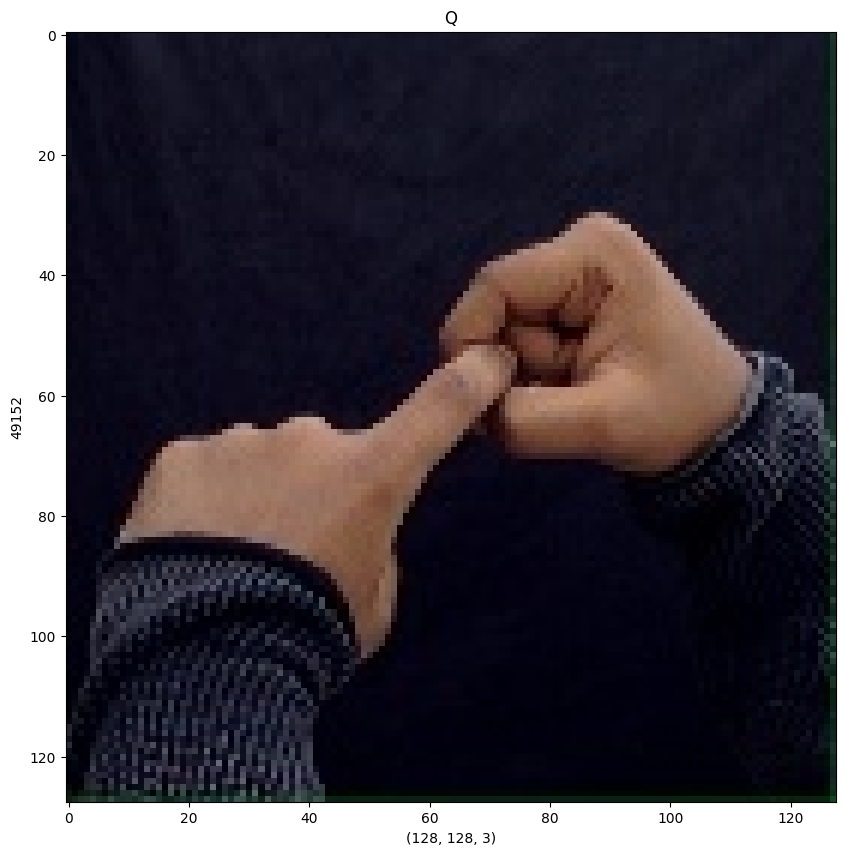

In [34]:
figure = plt.figure(figsize=(10,10))

Image_Sign = simple_vision(Main_Sign_Data["JPG"][33])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][33])
plt.imshow(Image_Sign)

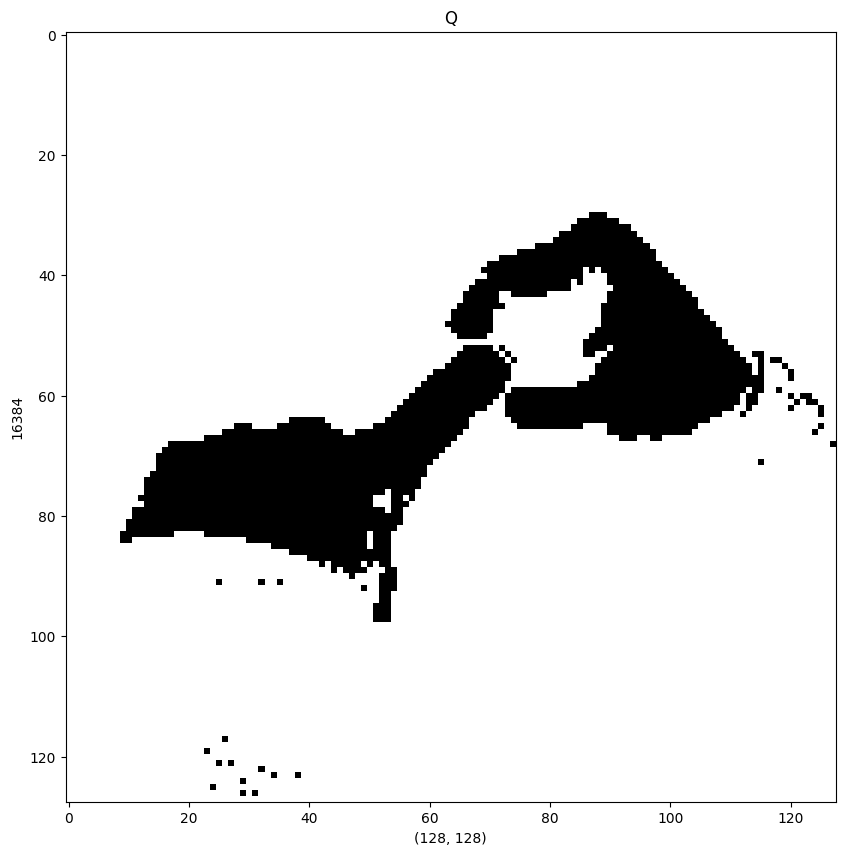

In [35]:
figure = plt.figure(figsize=(10,10))

Image_Sign = threshold_vision(Main_Sign_Data["JPG"][33])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][33])
plt.imshow(Image_Sign,cmap="gray")

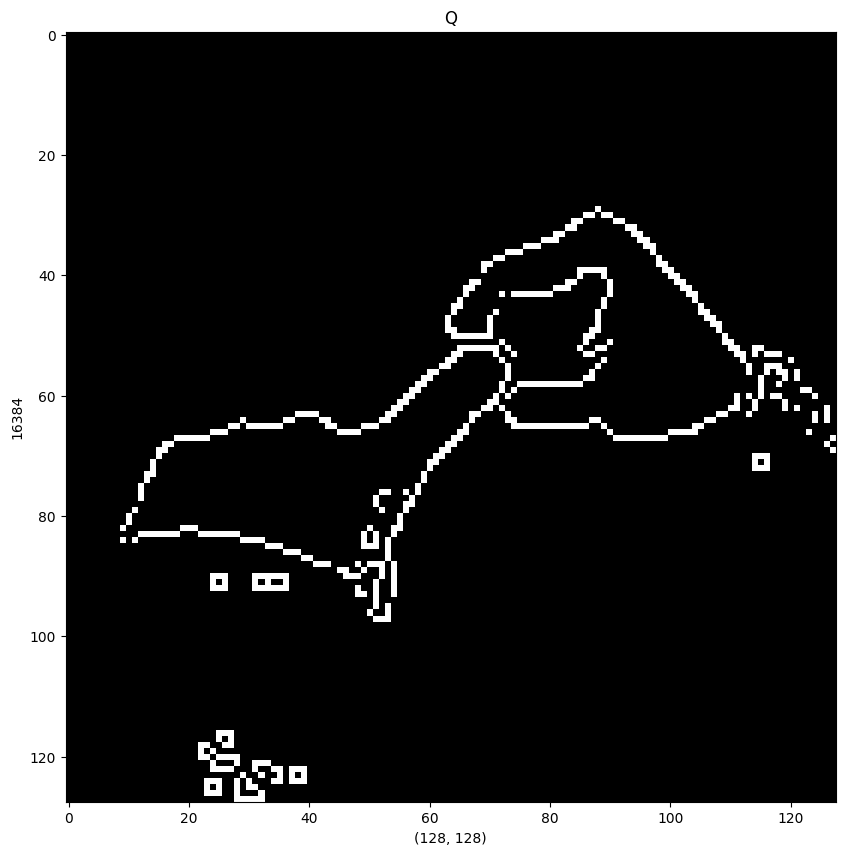

In [36]:
figure = plt.figure(figsize=(10,10))

Image_Sign = canny_vision(Main_Sign_Data["JPG"][33])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][33])
plt.imshow(Image_Sign,cmap="gray")

Text(0.5, 1.0, 'Q')

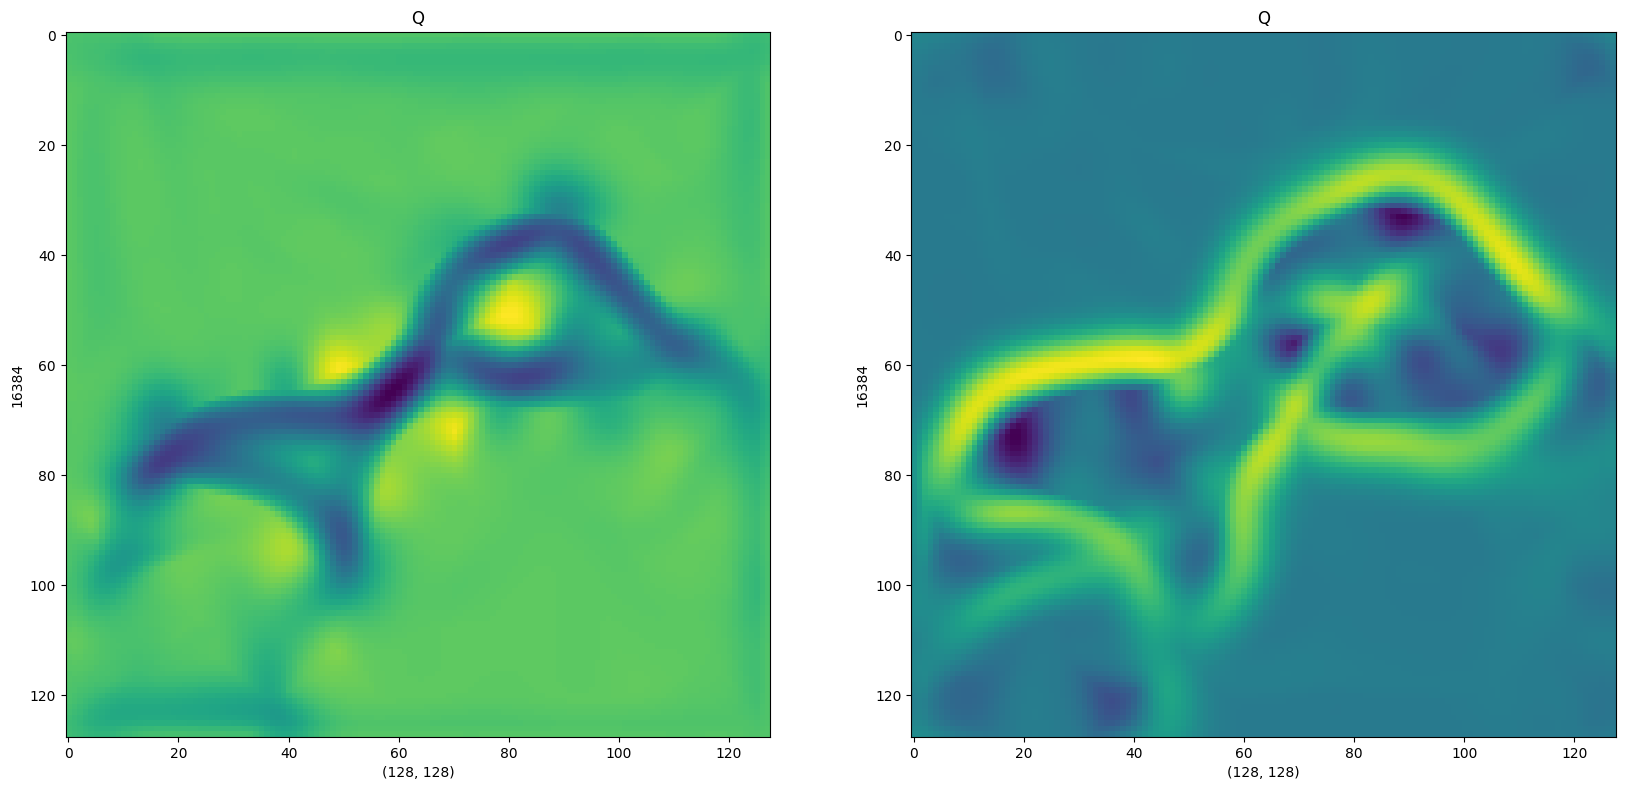

In [37]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Example_Image = cv2.cvtColor(cv2.imread(Main_Sign_Data["JPG"][33]),cv2.COLOR_BGR2GRAY)

Hessian_Mat = hessian_matrix(Example_Image,sigma=5,order="rc")
max_S,min_S = hessian_matrix_eigvals(Hessian_Mat)

axis[0].imshow(min_S)
axis[0].set_xlabel(min_S.shape)
axis[0].set_ylabel(min_S.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][33])
axis[1].imshow(max_S)
axis[1].set_xlabel(max_S.shape)
axis[1].set_ylabel(max_S.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][33])

Text(0.5, 1.0, 'Q')

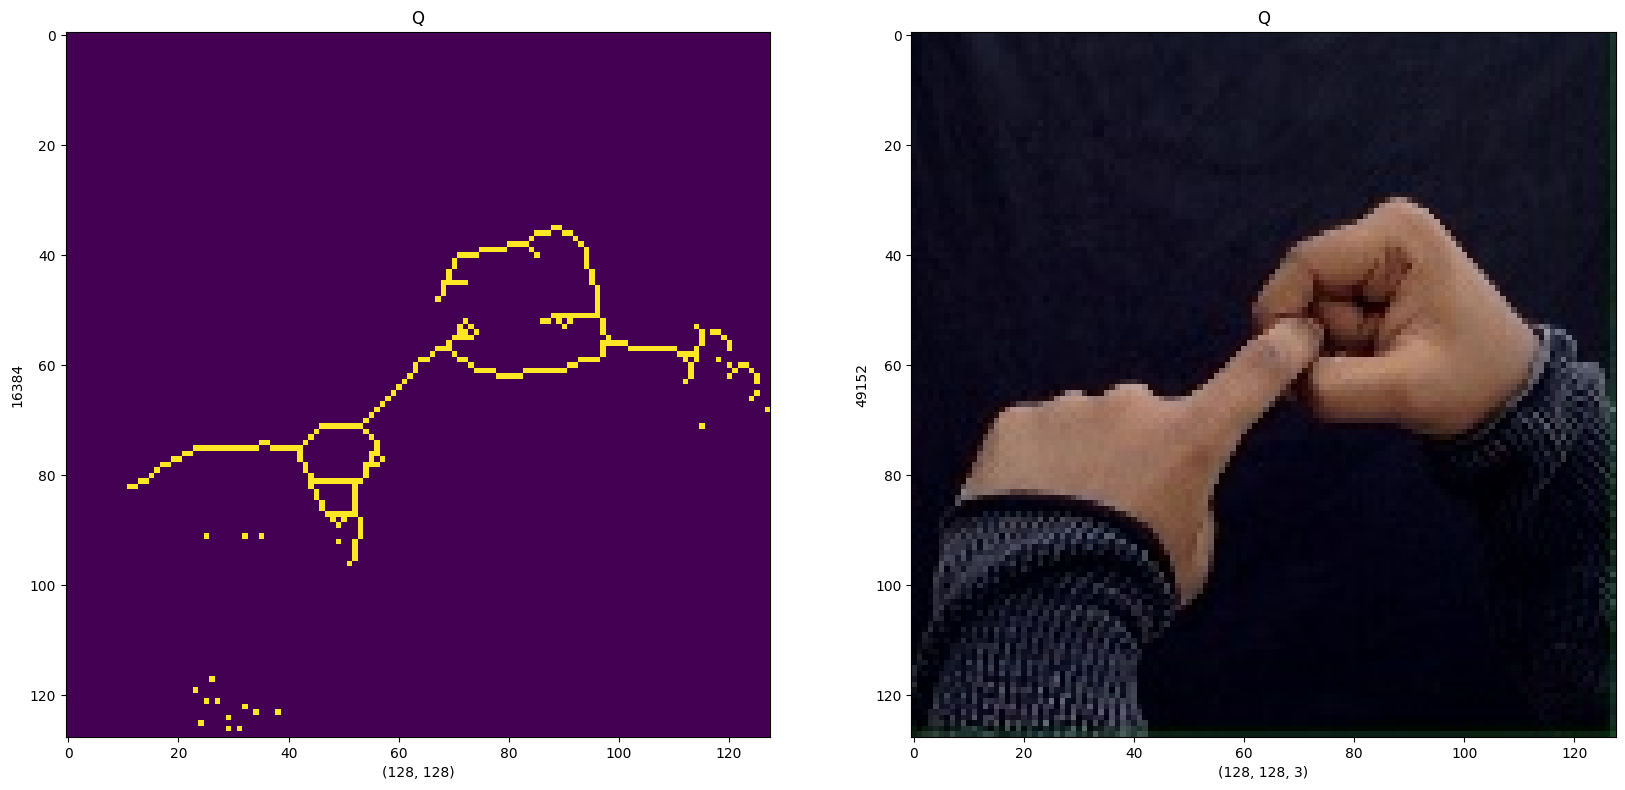

In [38]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Skel_Img = skeleton_morph_vision(Main_Sign_Data["JPG"][33])
Simple_Img = simple_vision(Main_Sign_Data["JPG"][33])

axis[0].imshow(Skel_Img)
axis[0].set_xlabel(Skel_Img.shape)
axis[0].set_ylabel(Skel_Img.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][33])
axis[1].imshow(Simple_Img)
axis[1].set_xlabel(Simple_Img.shape)
axis[1].set_ylabel(Simple_Img.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][33])

##### EXAMPLE II

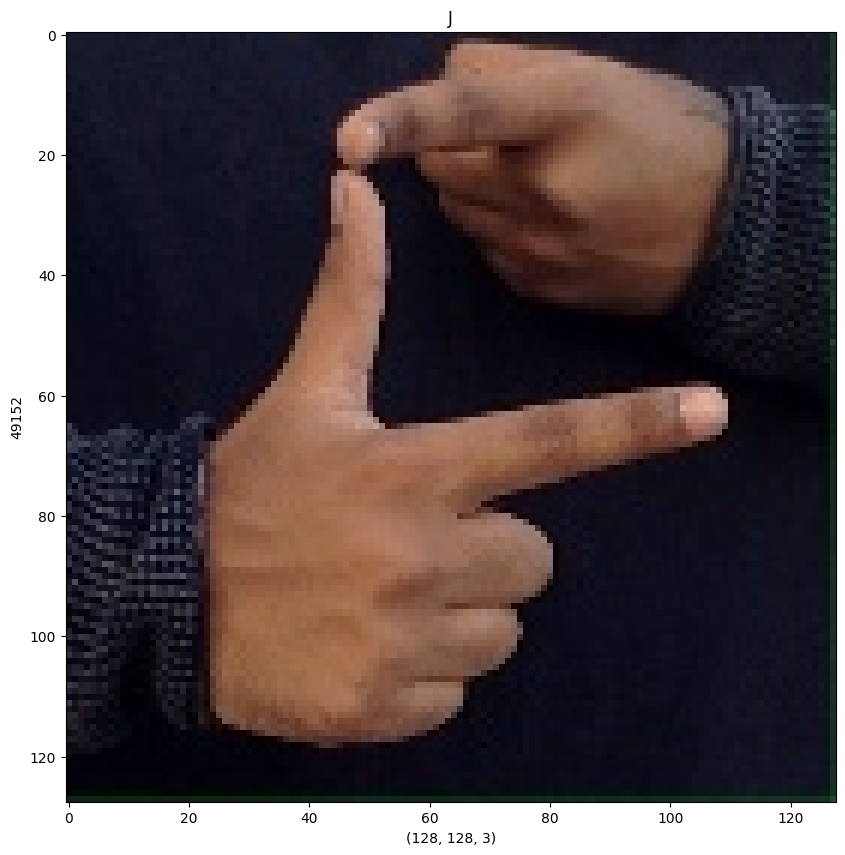

In [39]:
figure = plt.figure(figsize=(10,10))

Image_Sign = simple_vision(Main_Sign_Data["JPG"][41113])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][41113])
plt.imshow(Image_Sign)

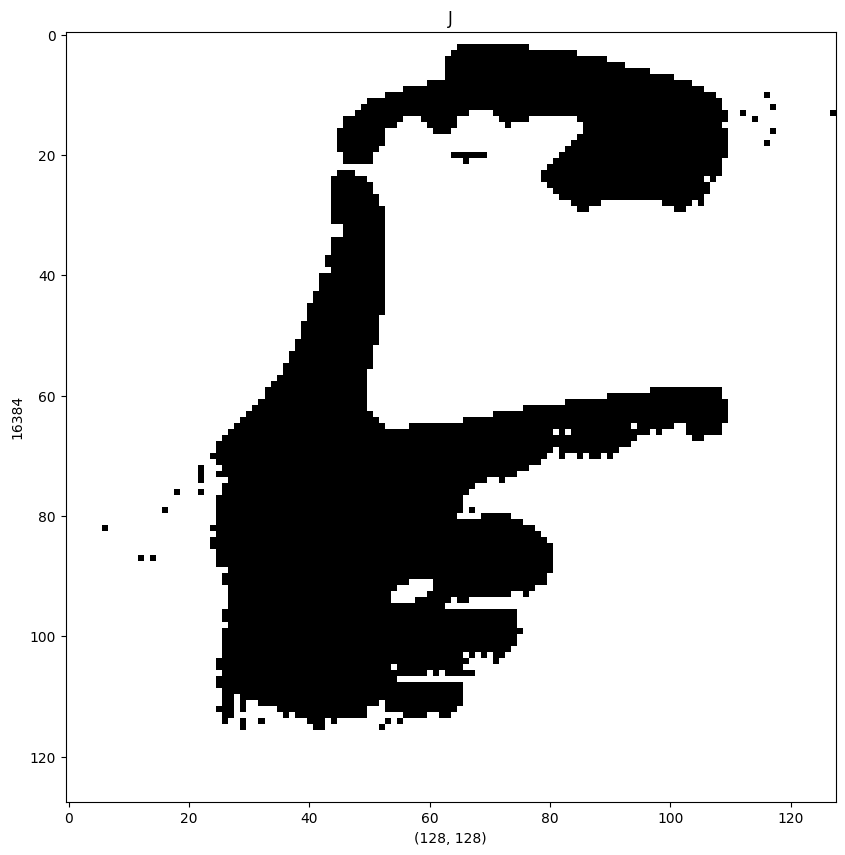

In [40]:
figure = plt.figure(figsize=(10,10))

Image_Sign = threshold_vision(Main_Sign_Data["JPG"][41113])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][41113])
plt.imshow(Image_Sign,cmap="gray")

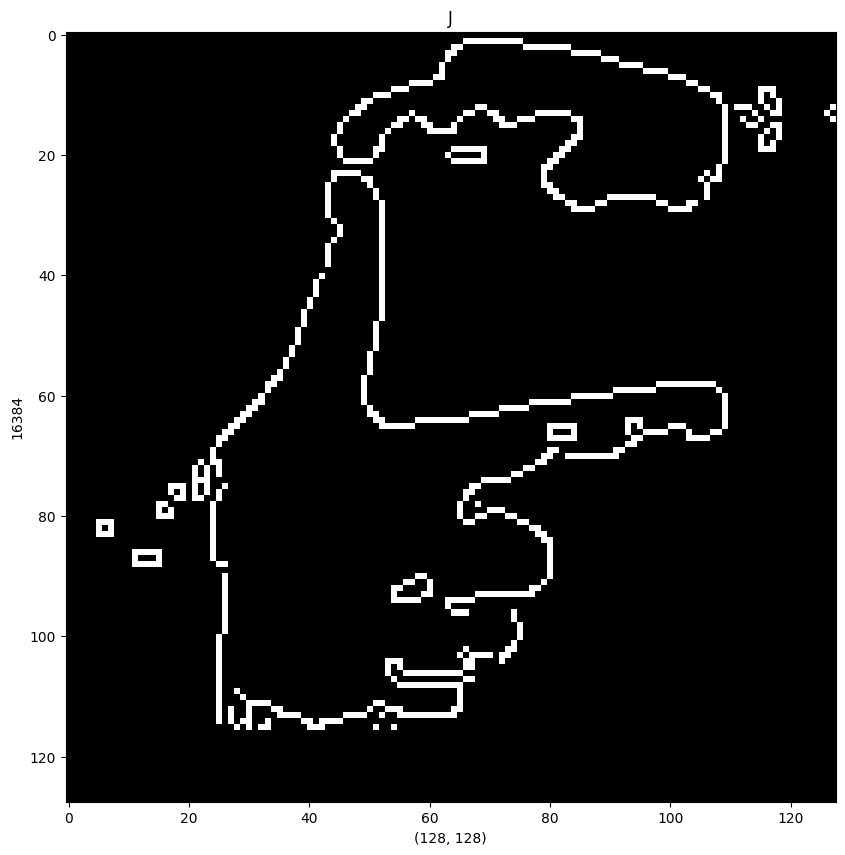

In [41]:
figure = plt.figure(figsize=(10,10))

Image_Sign = canny_vision(Main_Sign_Data["JPG"][41113])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][41113])
plt.imshow(Image_Sign,cmap="gray")

Text(0.5, 1.0, 'J')

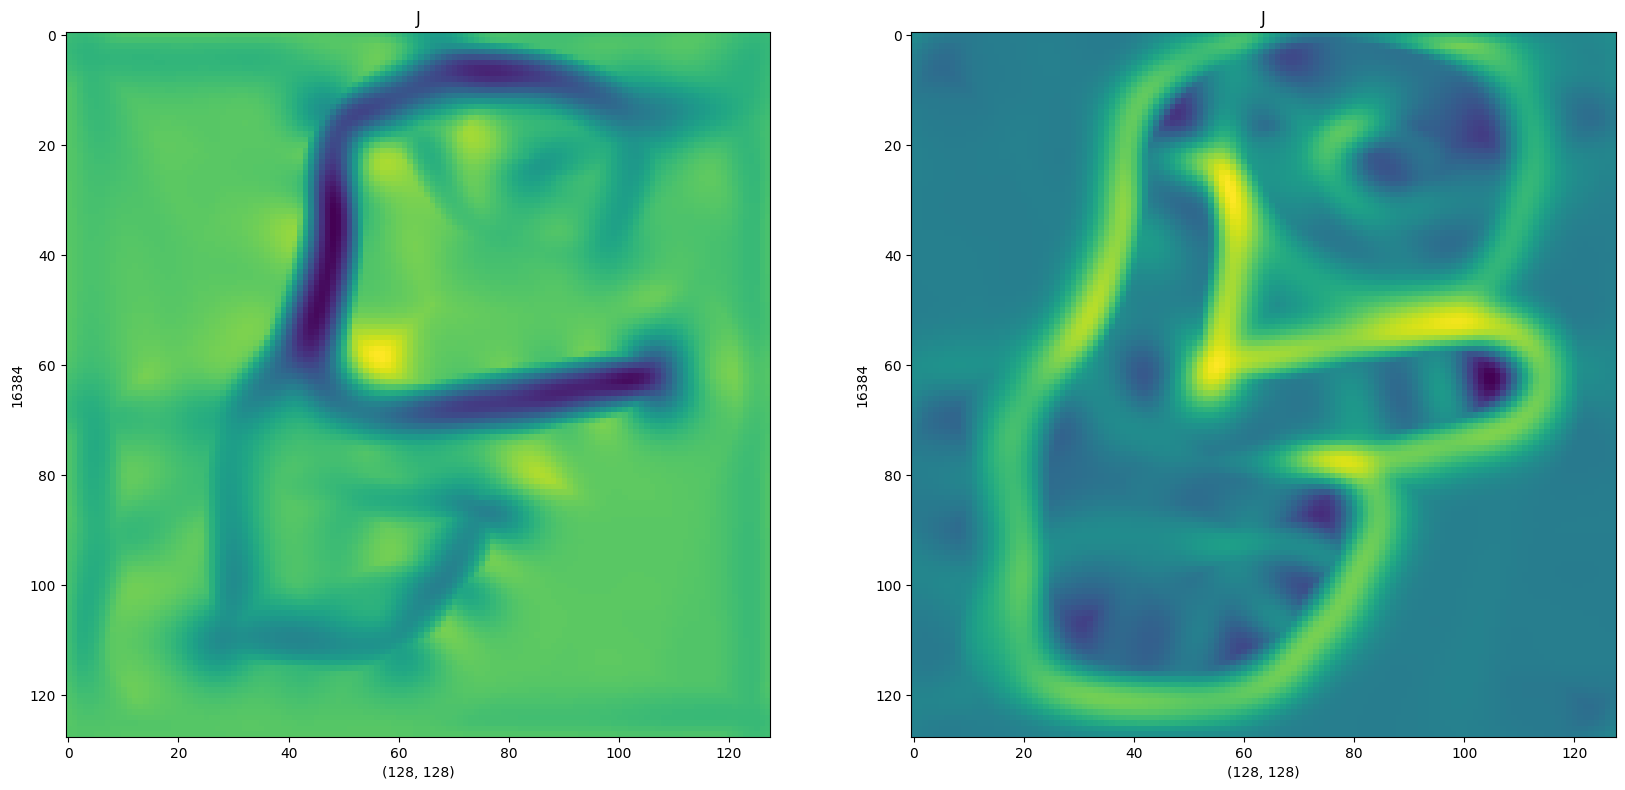

In [42]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Example_Image = cv2.cvtColor(cv2.imread(Main_Sign_Data["JPG"][41113]),cv2.COLOR_BGR2GRAY)

Hessian_Mat = hessian_matrix(Example_Image,sigma=5,order="rc")
max_S,min_S = hessian_matrix_eigvals(Hessian_Mat)

axis[0].imshow(min_S)
axis[0].set_xlabel(min_S.shape)
axis[0].set_ylabel(min_S.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][41113])
axis[1].imshow(max_S)
axis[1].set_xlabel(max_S.shape)
axis[1].set_ylabel(max_S.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][41113])

Text(0.5, 1.0, 'J')

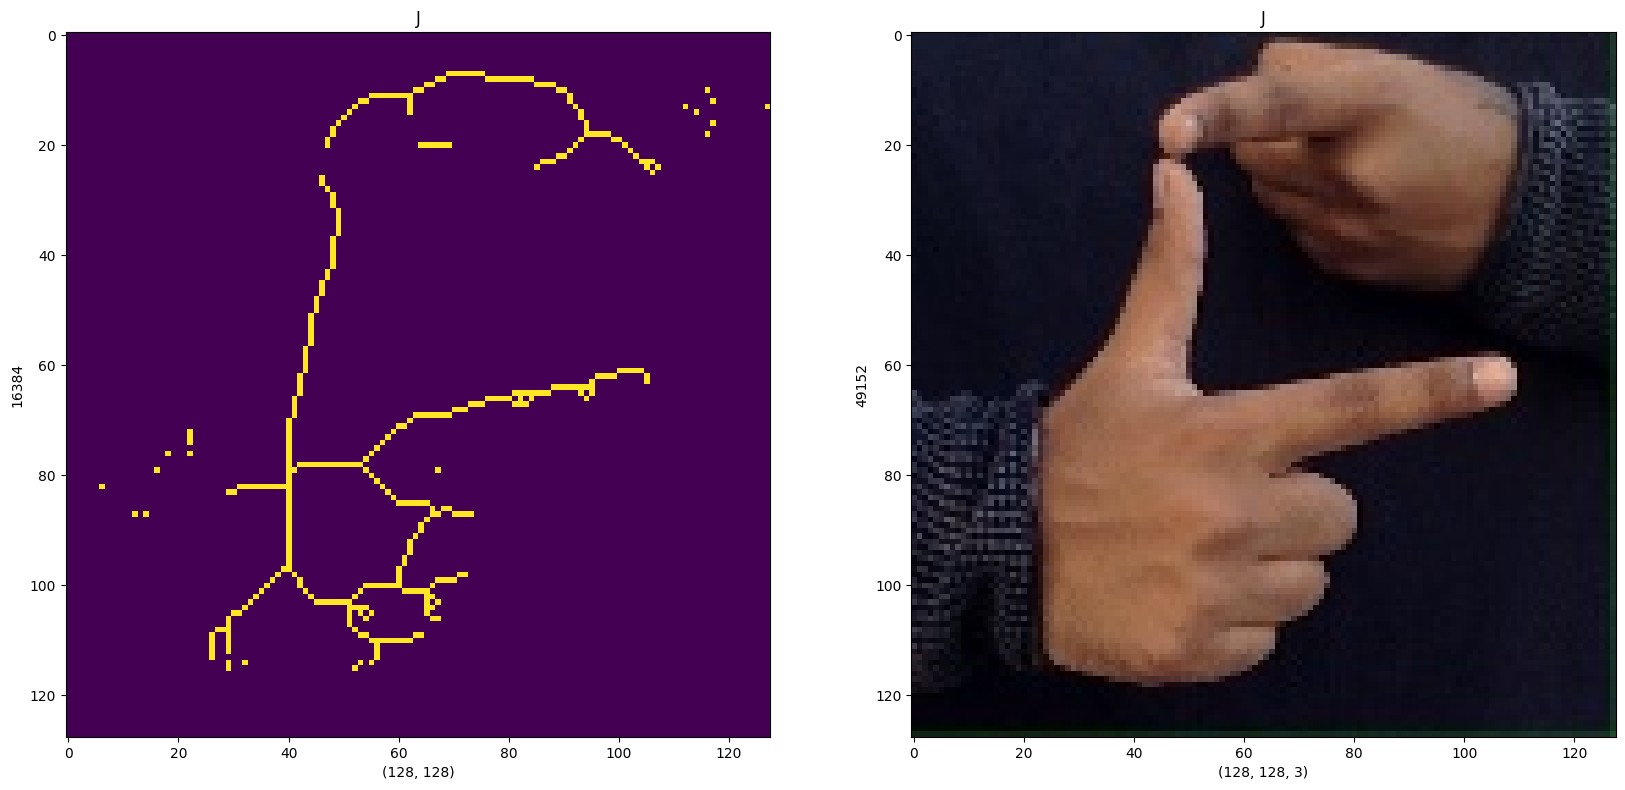

In [43]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Skel_Img = skeleton_morph_vision(Main_Sign_Data["JPG"][41113])
Simple_Img = simple_vision(Main_Sign_Data["JPG"][41113])

axis[0].imshow(Skel_Img)
axis[0].set_xlabel(Skel_Img.shape)
axis[0].set_ylabel(Skel_Img.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][41113])
axis[1].imshow(Simple_Img)
axis[1].set_xlabel(Simple_Img.shape)
axis[1].set_ylabel(Simple_Img.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][41113])

##### EXAMPLE III

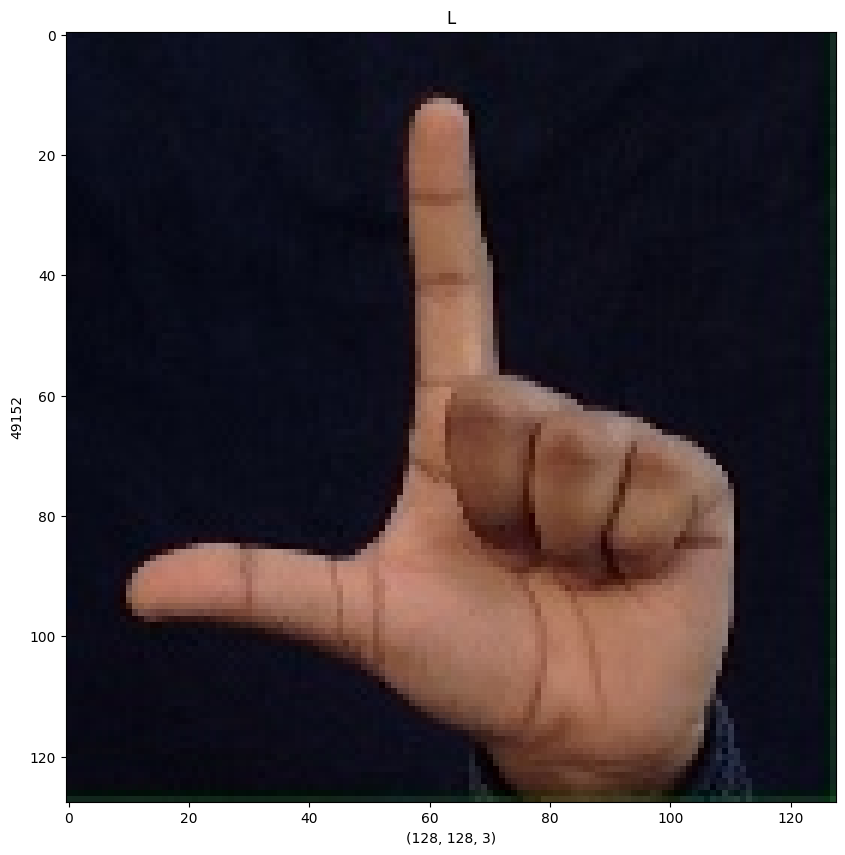

In [44]:
figure = plt.figure(figsize=(10,10))

Image_Sign = simple_vision(Main_Sign_Data["JPG"][22213])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][22213])
plt.imshow(Image_Sign)

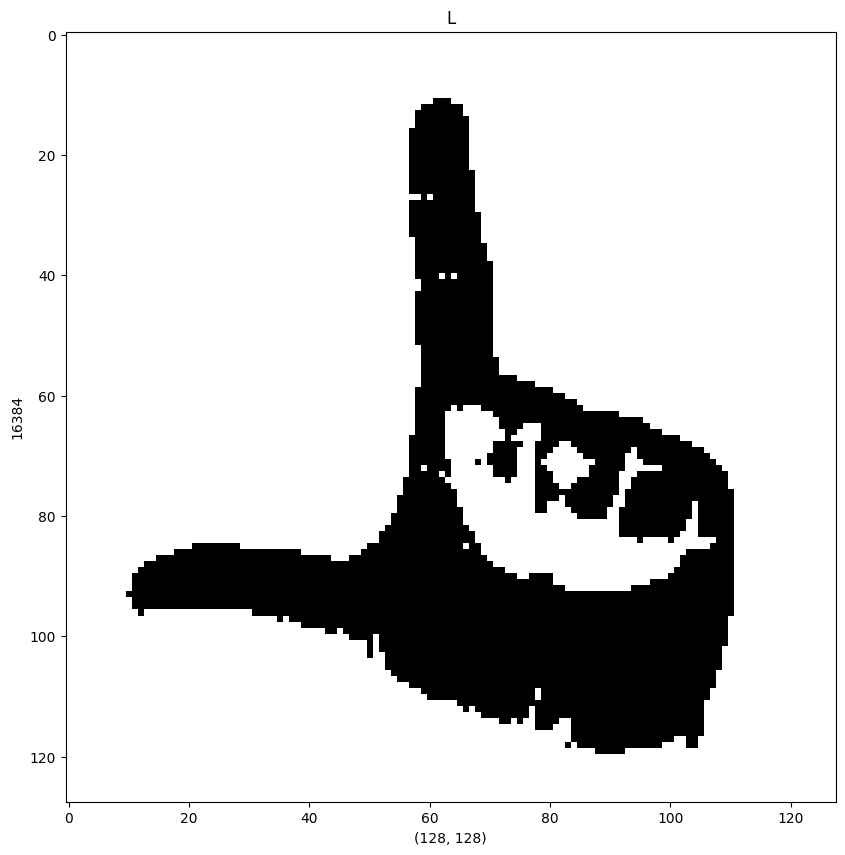

In [45]:
figure = plt.figure(figsize=(10,10))

Image_Sign = threshold_vision(Main_Sign_Data["JPG"][22213])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][22213])
plt.imshow(Image_Sign,cmap="gray")

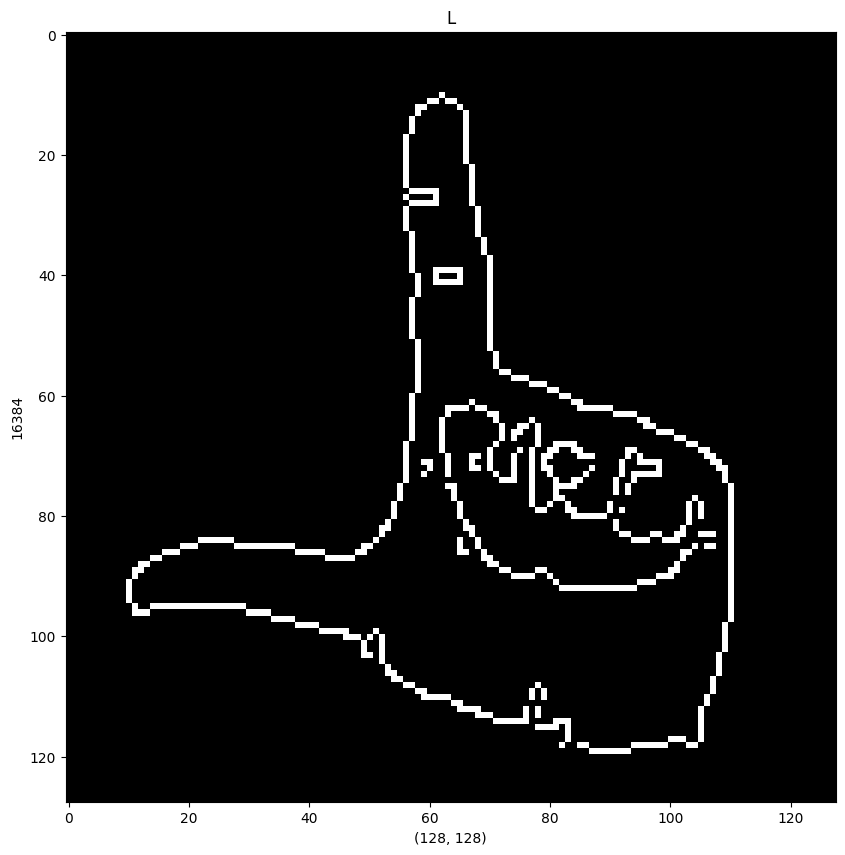

In [46]:
figure = plt.figure(figsize=(10,10))

Image_Sign = canny_vision(Main_Sign_Data["JPG"][22213])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][22213])
plt.imshow(Image_Sign,cmap="gray")

Text(0.5, 1.0, 'L')

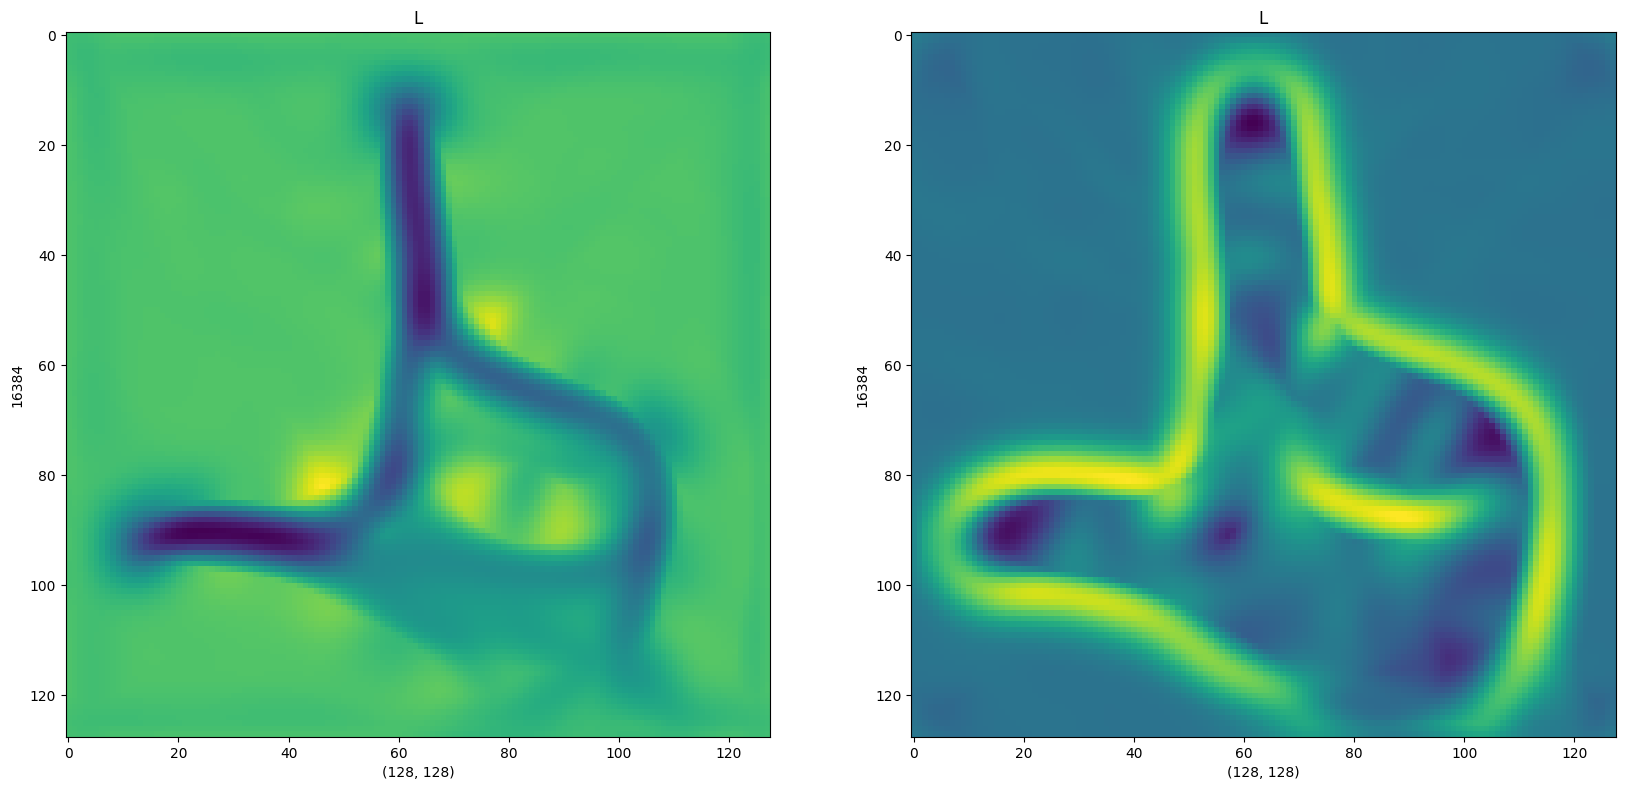

In [47]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Example_Image = cv2.cvtColor(cv2.imread(Main_Sign_Data["JPG"][22213]),cv2.COLOR_BGR2GRAY)

Hessian_Mat = hessian_matrix(Example_Image,sigma=5,order="rc")
max_S,min_S = hessian_matrix_eigvals(Hessian_Mat)

axis[0].imshow(min_S)
axis[0].set_xlabel(min_S.shape)
axis[0].set_ylabel(min_S.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][22213])
axis[1].imshow(max_S)
axis[1].set_xlabel(max_S.shape)
axis[1].set_ylabel(max_S.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][22213])

Text(0.5, 1.0, 'L')

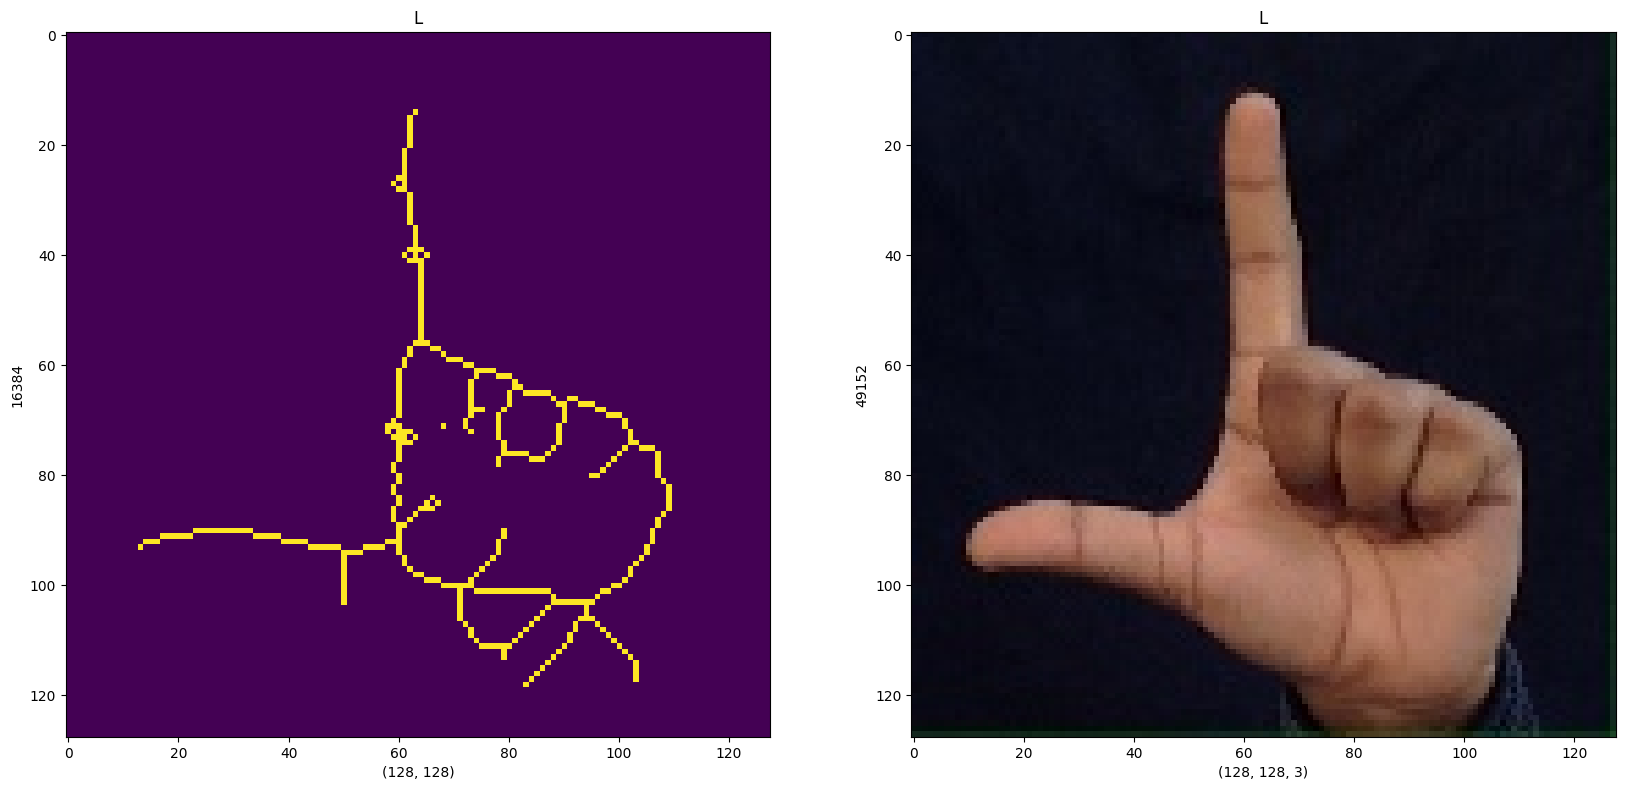

In [48]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Skel_Img = skeleton_morph_vision(Main_Sign_Data["JPG"][22213])
Simple_Img = simple_vision(Main_Sign_Data["JPG"][22213])

axis[0].imshow(Skel_Img)
axis[0].set_xlabel(Skel_Img.shape)
axis[0].set_ylabel(Skel_Img.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][22213])
axis[1].imshow(Simple_Img)
axis[1].set_xlabel(Simple_Img.shape)
axis[1].set_ylabel(Simple_Img.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][22213])

##### EXAMPLE IV

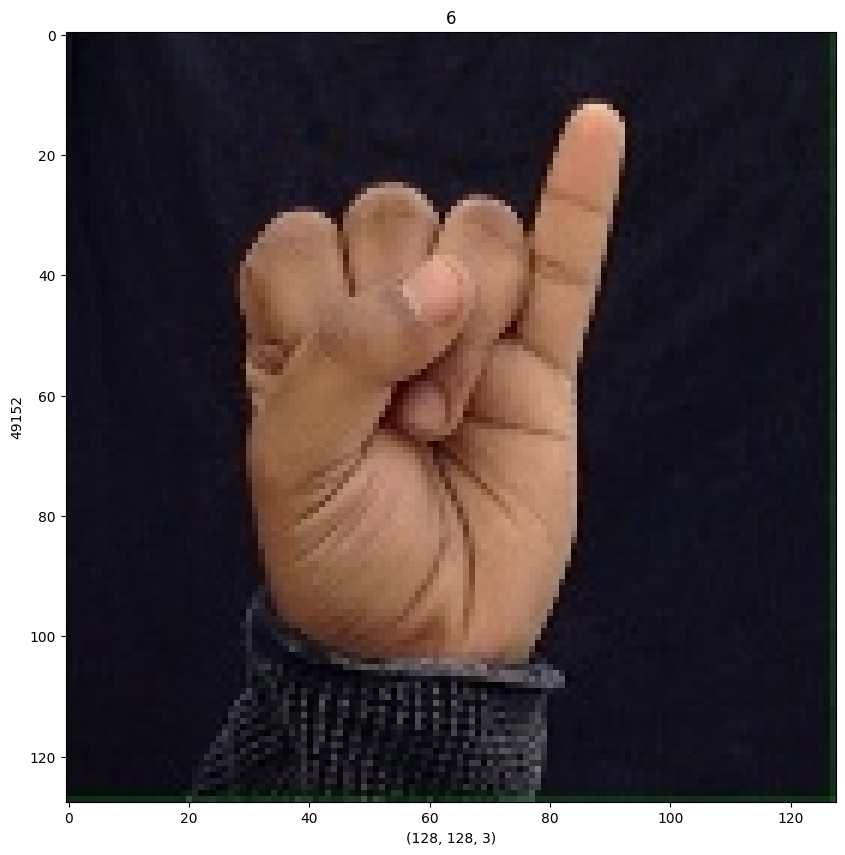

In [49]:
figure = plt.figure(figsize=(10,10))

Image_Sign = simple_vision(Main_Sign_Data["JPG"][10000])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][10000])
plt.imshow(Image_Sign)

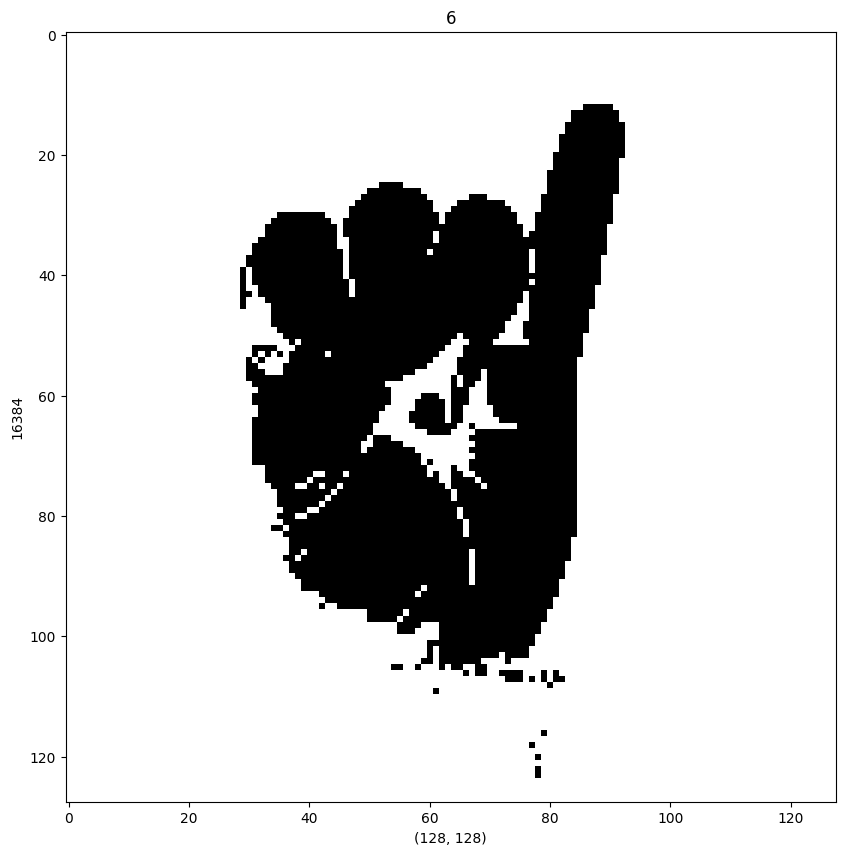

In [50]:
figure = plt.figure(figsize=(10,10))

Image_Sign = threshold_vision(Main_Sign_Data["JPG"][10000])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][10000])
plt.imshow(Image_Sign,cmap="gray")

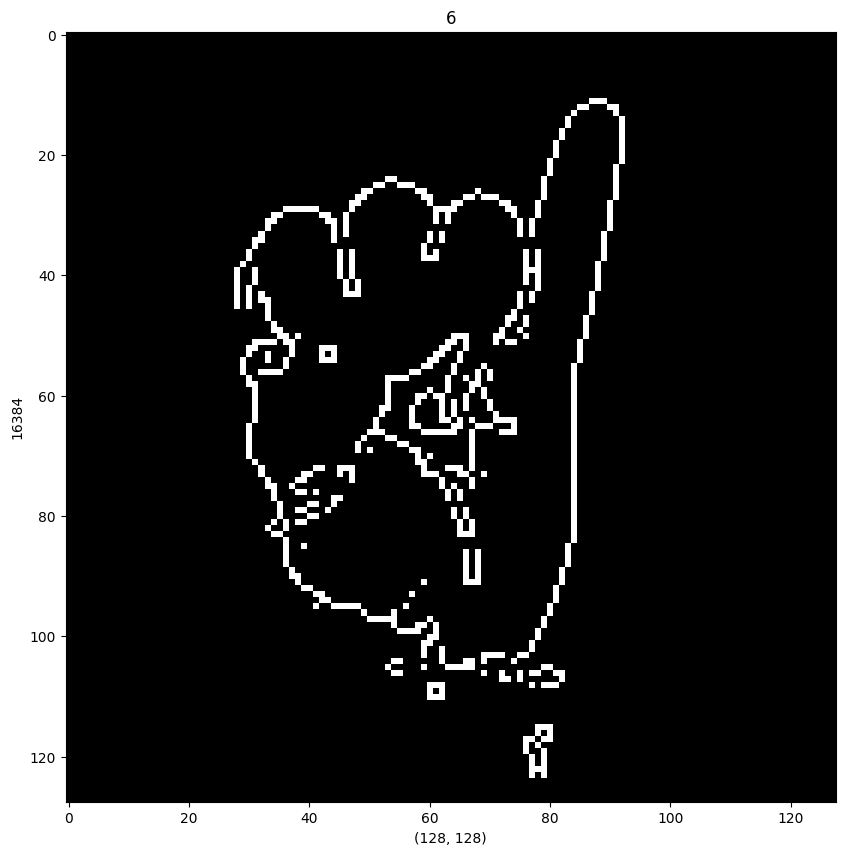

In [51]:
figure = plt.figure(figsize=(10,10))

Image_Sign = canny_vision(Main_Sign_Data["JPG"][10000])

plt.xlabel(Image_Sign.shape)
plt.ylabel(Image_Sign.size)
plt.title(Main_Sign_Data["CATEGORY"][10000])
plt.imshow(Image_Sign,cmap="gray")

Text(0, 0.5, '16384')

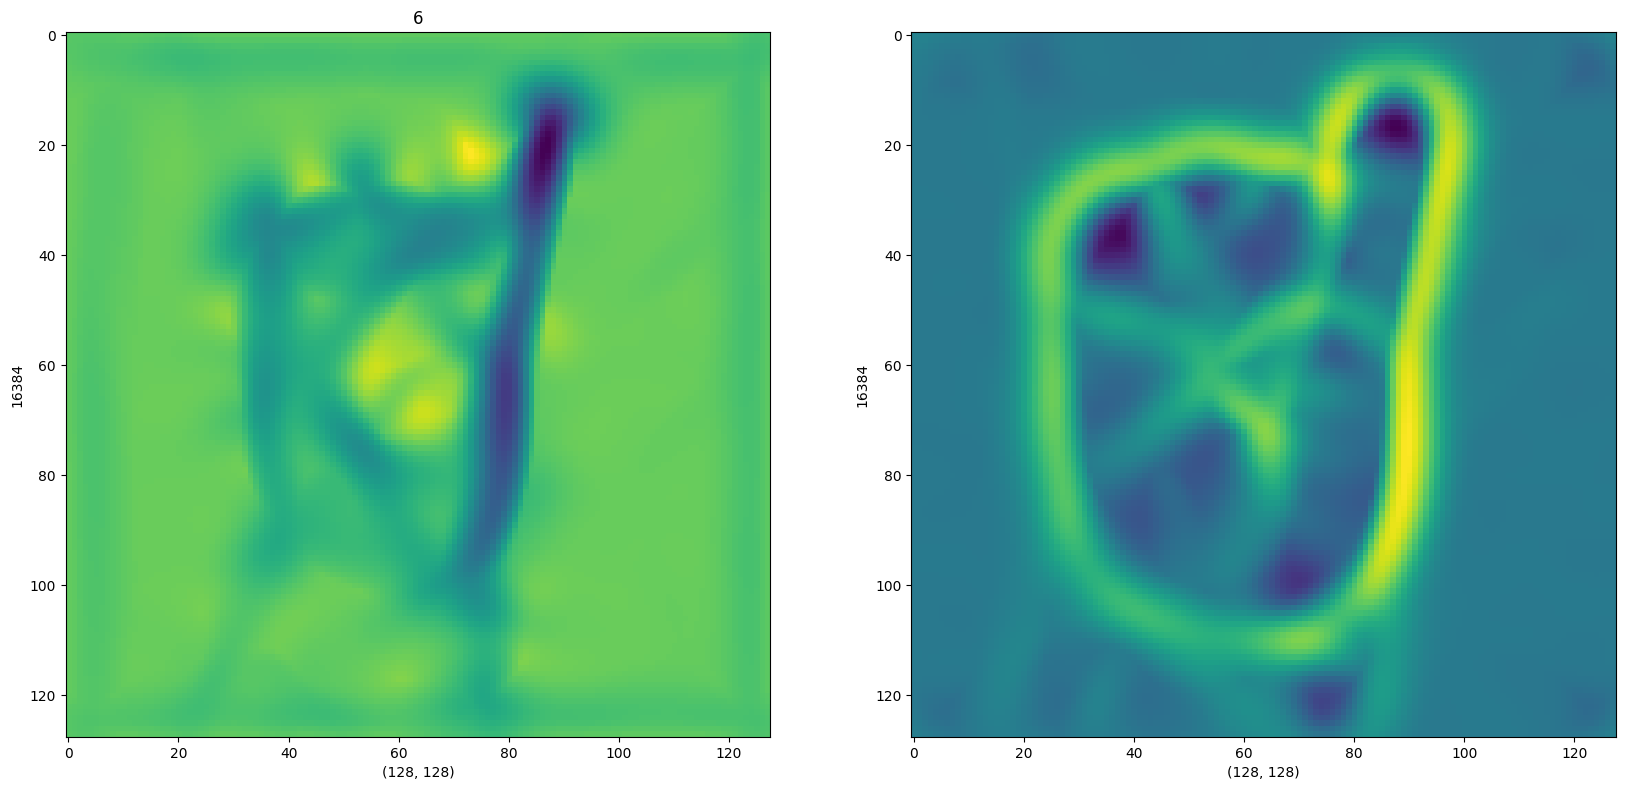

In [52]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Example_Image = cv2.cvtColor(cv2.imread(Main_Sign_Data["JPG"][10000]),cv2.COLOR_BGR2GRAY)

Hessian_Mat = hessian_matrix(Example_Image,sigma=5,order="rc")
max_S,min_S = hessian_matrix_eigvals(Hessian_Mat)

axis[0].imshow(min_S)
axis[0].set_xlabel(min_S.shape)
axis[0].set_ylabel(min_S.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][10000])
axis[1].imshow(max_S)
axis[1].set_xlabel(max_S.shape)
axis[1].set_ylabel(max_S.size)

Text(0.5, 1.0, '6')

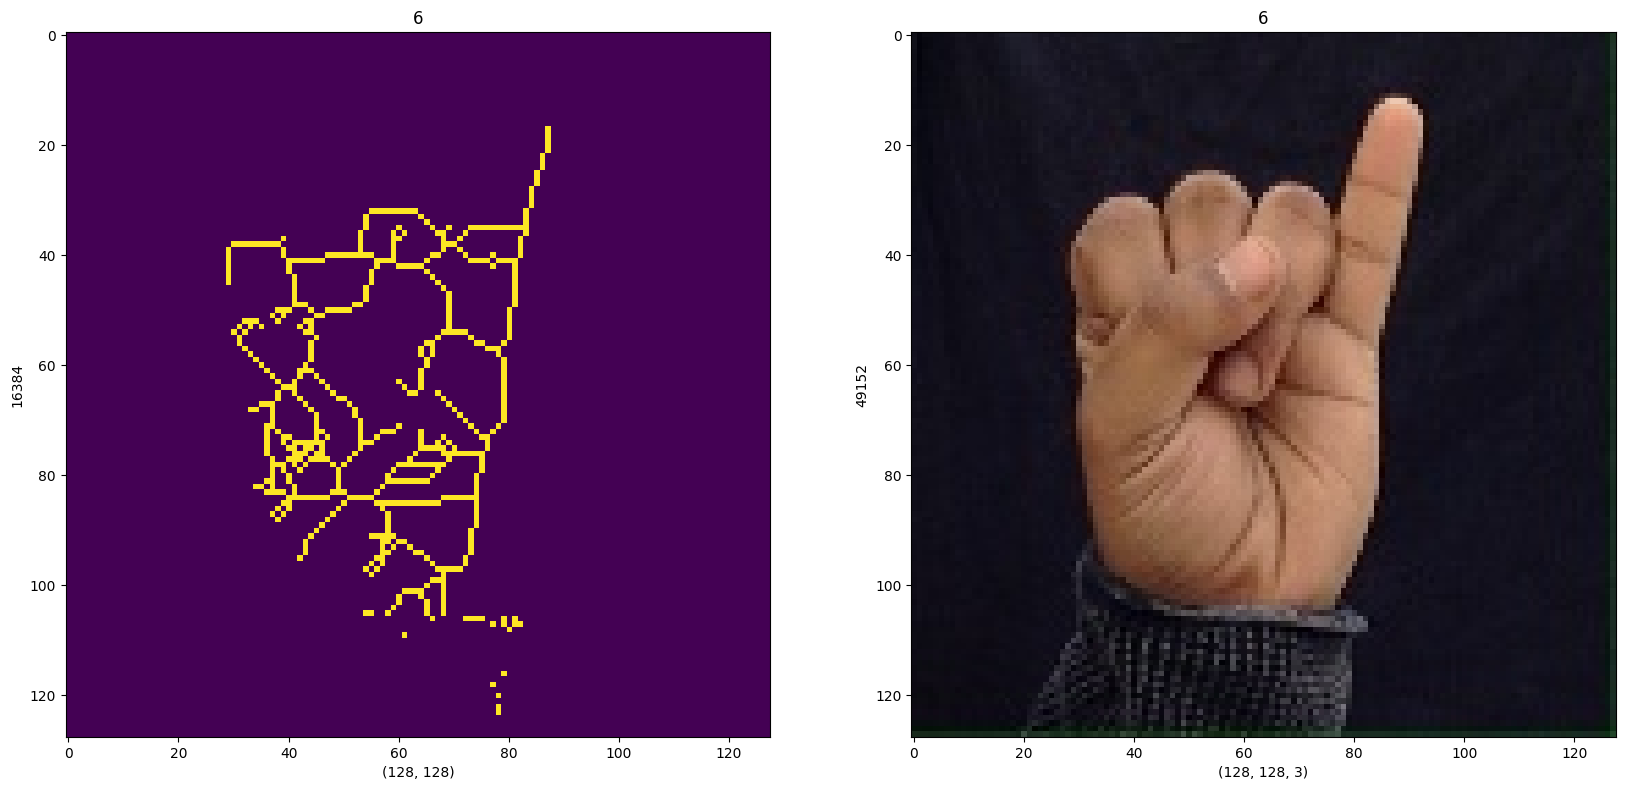

In [53]:
figure,axis = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

Skel_Img = skeleton_morph_vision(Main_Sign_Data["JPG"][10000])
Simple_Img = simple_vision(Main_Sign_Data["JPG"][10000])

axis[0].imshow(Skel_Img)
axis[0].set_xlabel(Skel_Img.shape)
axis[0].set_ylabel(Skel_Img.size)
axis[0].set_title(Main_Sign_Data["CATEGORY"][10000])
axis[1].imshow(Simple_Img)
axis[1].set_xlabel(Simple_Img.shape)
axis[1].set_ylabel(Simple_Img.size)
axis[1].set_title(Main_Sign_Data["CATEGORY"][10000])

# SPLITTING DATA

In [54]:
X_Train,X_Test = train_test_split(Main_Sign_Data,train_size=0.9,random_state=123,shuffle=True)

In [55]:
print(X_Train.shape)
print(X_Test.shape)

(38470, 2)
(4275, 2)


In [56]:
print(type(X_Train))
print(type(X_Test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


# IMAGE DATA GENERATOR PROCESS

#### GENERATOR STRUCTURE

In [57]:
Train_IMG_Generator = ImageDataGenerator(rescale=1./255,
                                        zoom_range=0.5,
                                        shear_range=0.5,
                                        brightness_range=[0.6,1.0],
                                        rotation_range=35,
                                        width_shift_range=0.1,
                                        height_shift_range=0.1,
                                        vertical_flip=True,
                                         featurewise_std_normalization=False,
                                         samplewise_center=False,
                                         samplewise_std_normalization=False,
                                        fill_mode="nearest",
                                        validation_split=0.1)

In [58]:
Test_IMG_Generator = ImageDataGenerator(rescale=1./255)

#### HOW TO LOOK BY GENERATOR

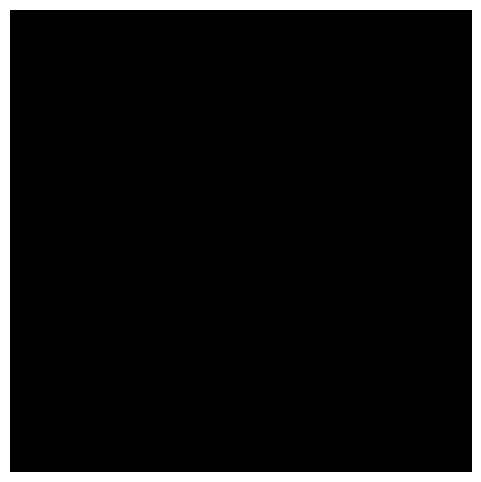

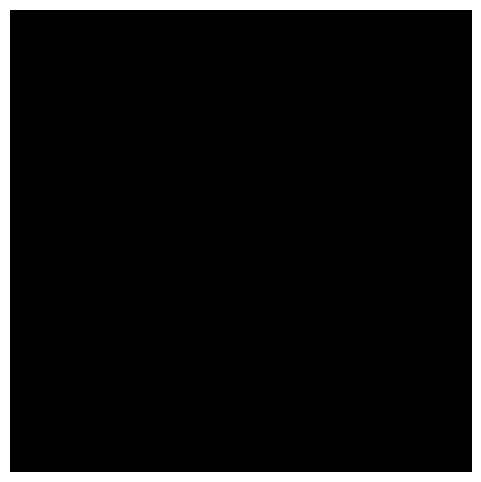

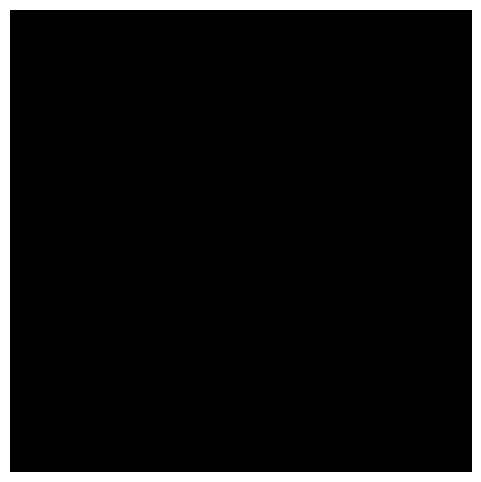

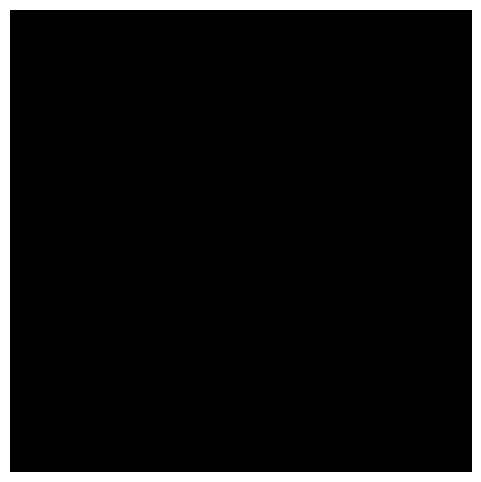

In [59]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# pick one image
Example_Img = simple_vision(X_Train['JPG'][3])

# reshape (add batch dimension)
Example_Img = Example_Img.reshape((1,) + Example_Img.shape)

i = 0 

for batch in Train_IMG_Generator.flow(Example_Img, batch_size=32):
    
    plt.figure(figsize=(6,6))
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")
    
    i += 1
    if i == 4:
        break
        
plt.show()

#### APPLYING

In [60]:
Train_Set = Train_IMG_Generator.flow_from_dataframe(dataframe=X_Train,
                                                   x_col="JPG",
                                                   y_col="CATEGORY",
                                                   batch_size=32,
                                                   class_mode="categorical",
                                                   color_mode="grayscale",
                                                   subset="training")

Found 34623 validated image filenames belonging to 35 classes.


In [61]:
Validation_Set = Train_IMG_Generator.flow_from_dataframe(dataframe=X_Train,
                                                   x_col="JPG",
                                                   y_col="CATEGORY",
                                                   batch_size=32,
                                                   class_mode="categorical",
                                                   color_mode="grayscale",
                                                   subset="validation")

Found 3847 validated image filenames belonging to 35 classes.


In [62]:
Test_Set = Test_IMG_Generator.flow_from_dataframe(dataframe=X_Test,
                                                   x_col="JPG",
                                                   y_col="CATEGORY",
                                                   batch_size=32,
                                                   class_mode="categorical",
                                                   color_mode="grayscale",
                                                   shuffle=False)

Found 4275 validated image filenames belonging to 35 classes.


In [63]:
print("TRAIN: ")
print(Train_Set.class_indices)
print(Train_Set.classes[0:5])
print(Train_Set.image_shape)
print("---"*20)
print("VALIDATION: ")
print(Validation_Set.class_indices)
print(Validation_Set.classes[0:5])
print(Validation_Set.image_shape)
print("---"*20)
print("TEST: ")
print(Test_Set.class_indices)
print(Test_Set.classes[0:5])
print(Test_Set.image_shape)

TRAIN: 
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'O': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}
[5, 34, 25, 12, 28]
(256, 256, 1)
------------------------------------------------------------
VALIDATION: 
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'O': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}
[24, 6, 12, 28, 17]
(256, 256, 1)
------------------------------------------------------------
TEST: 
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19,

# MODEL

#### PARAMETERS

In [64]:
COMPILE_OPTIMIZER = "adam"
COMPILE_LOSS = "categorical_crossentropy"
COMPILE_METRICS = ["accuracy"]
INPUT_DIM = (256,256,1)
OUTPUT_DIM = 35

In [65]:
Early_Stopper = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True
)

Checkpoint_Model = tf.keras.callbacks.ModelCheckpoint(
    filepath="./best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False
)

In [66]:
Model = Sequential()

Model.add(Conv2D(24,(3,3),activation="relu",input_shape=INPUT_DIM))
Model.add(BatchNormalization())
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(64,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(64,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(128,(3,3),activation="relu",padding="same"))
Model.add(Conv2D(128,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(256,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Flatten())
Model.add(Dense(2352,activation="relu"))
Model.add(Dropout(0.5))
Model.add(Dense(OUTPUT_DIM,activation="softmax"))

In [ ]:
Model.compile(optimizer=COMPILE_OPTIMIZER,loss=COMPILE_LOSS,metrics=COMPILE_METRICS) 

In [68]:
CNN_Model = Model.fit(Train_Set,
                      validation_data=Validation_Set,
                      callbacks=[Early_Stopper,Checkpoint_Model],
                      epochs=50)

Epoch 1/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2090s 2s/step - accuracy: 0.7544 - loss: 0.7870 - val_accuracy: 0.9155 - val_loss: 0.6938
Epoch 2/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1936s 2s/step - accuracy: 0.9444 - loss: 0.1701 - val_accuracy: 0.8721 - val_loss: 0.5851
Epoch 3/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1933s 2s/step - accuracy: 0.9648 - loss: 0.1130 - val_accuracy: 0.9758 - val_loss: 0.1471
Epoch 4/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1927s 2s/step - accuracy: 0.9742 - loss: 0.0843 - val_accuracy: 0.9285 - val_loss: 0.3415
Epoch 5/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1934s 2s/step - accuracy: 0.9751 - loss: 0.0836 - val_accuracy: 0.9860 - val_loss: 0.1399
Epoch 6/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1971s 2s/step - accuracy: 0.9819 - loss: 0.0614 - val_accuracy: 0.9670 - val_loss: 0.1687
Epoch 7/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1962s 2s/step - accuracy: 0.9839 - loss: 0.0551 - val_accuracy: 0.9309 - val_loss: 0.3178
Epoch 8/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1996s 2s/step - accuracy: 0.9853 -

In [69]:
Model.save("Prediction_Model.h5")

<Axes: >

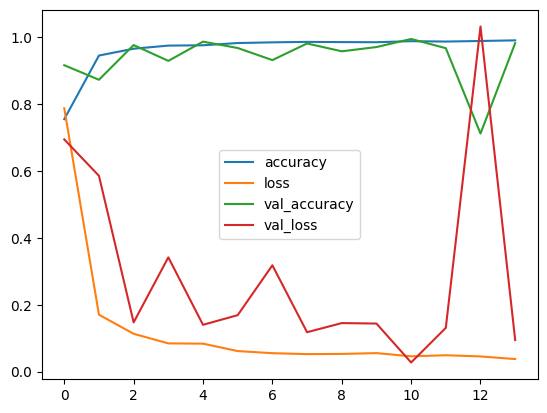

In [70]:
Grap_Data = pd.DataFrame(CNN_Model.history)
Grap_Data.plot()

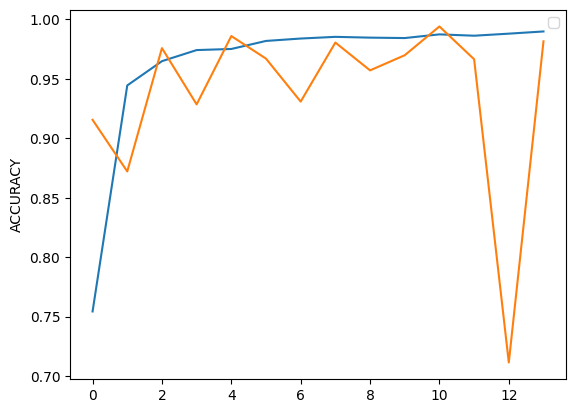

In [71]:
plt.plot(CNN_Model.history["accuracy"])
plt.plot(CNN_Model.history["val_accuracy"])
plt.ylabel("ACCURACY")
plt.legend()
plt.show()

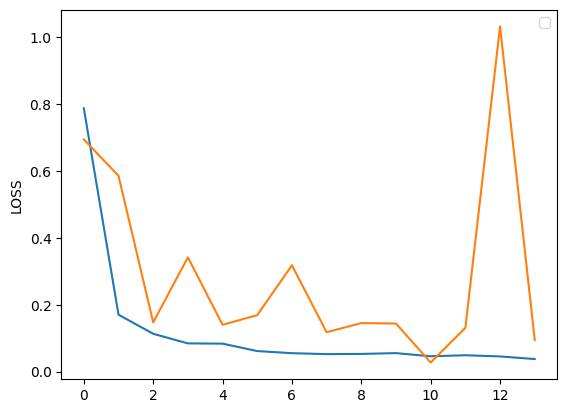

In [72]:
plt.plot(CNN_Model.history["loss"])
plt.plot(CNN_Model.history["val_loss"])
plt.ylabel("LOSS")
plt.legend()
plt.show()

In [73]:
Model_Results = Model.evaluate(Test_Set)
print("LOSS:  " + "%.4f" % Model_Results[0])
print("ACCURACY:  " + "%.2f" % Model_Results[1])

134/134 ━━━━━━━━━━━━━━━━━━━━ 70s 522ms/step - accuracy: 0.9857 - loss: 0.0422
LOSS:  0.0422
ACCURACY:  0.99


In [74]:
Model_Test_Prediction = Model.predict(Test_Set)
Model_Test_Prediction = Model_Test_Prediction.argmax(axis=-1)

134/134 ━━━━━━━━━━━━━━━━━━━━ 35s 260ms/step


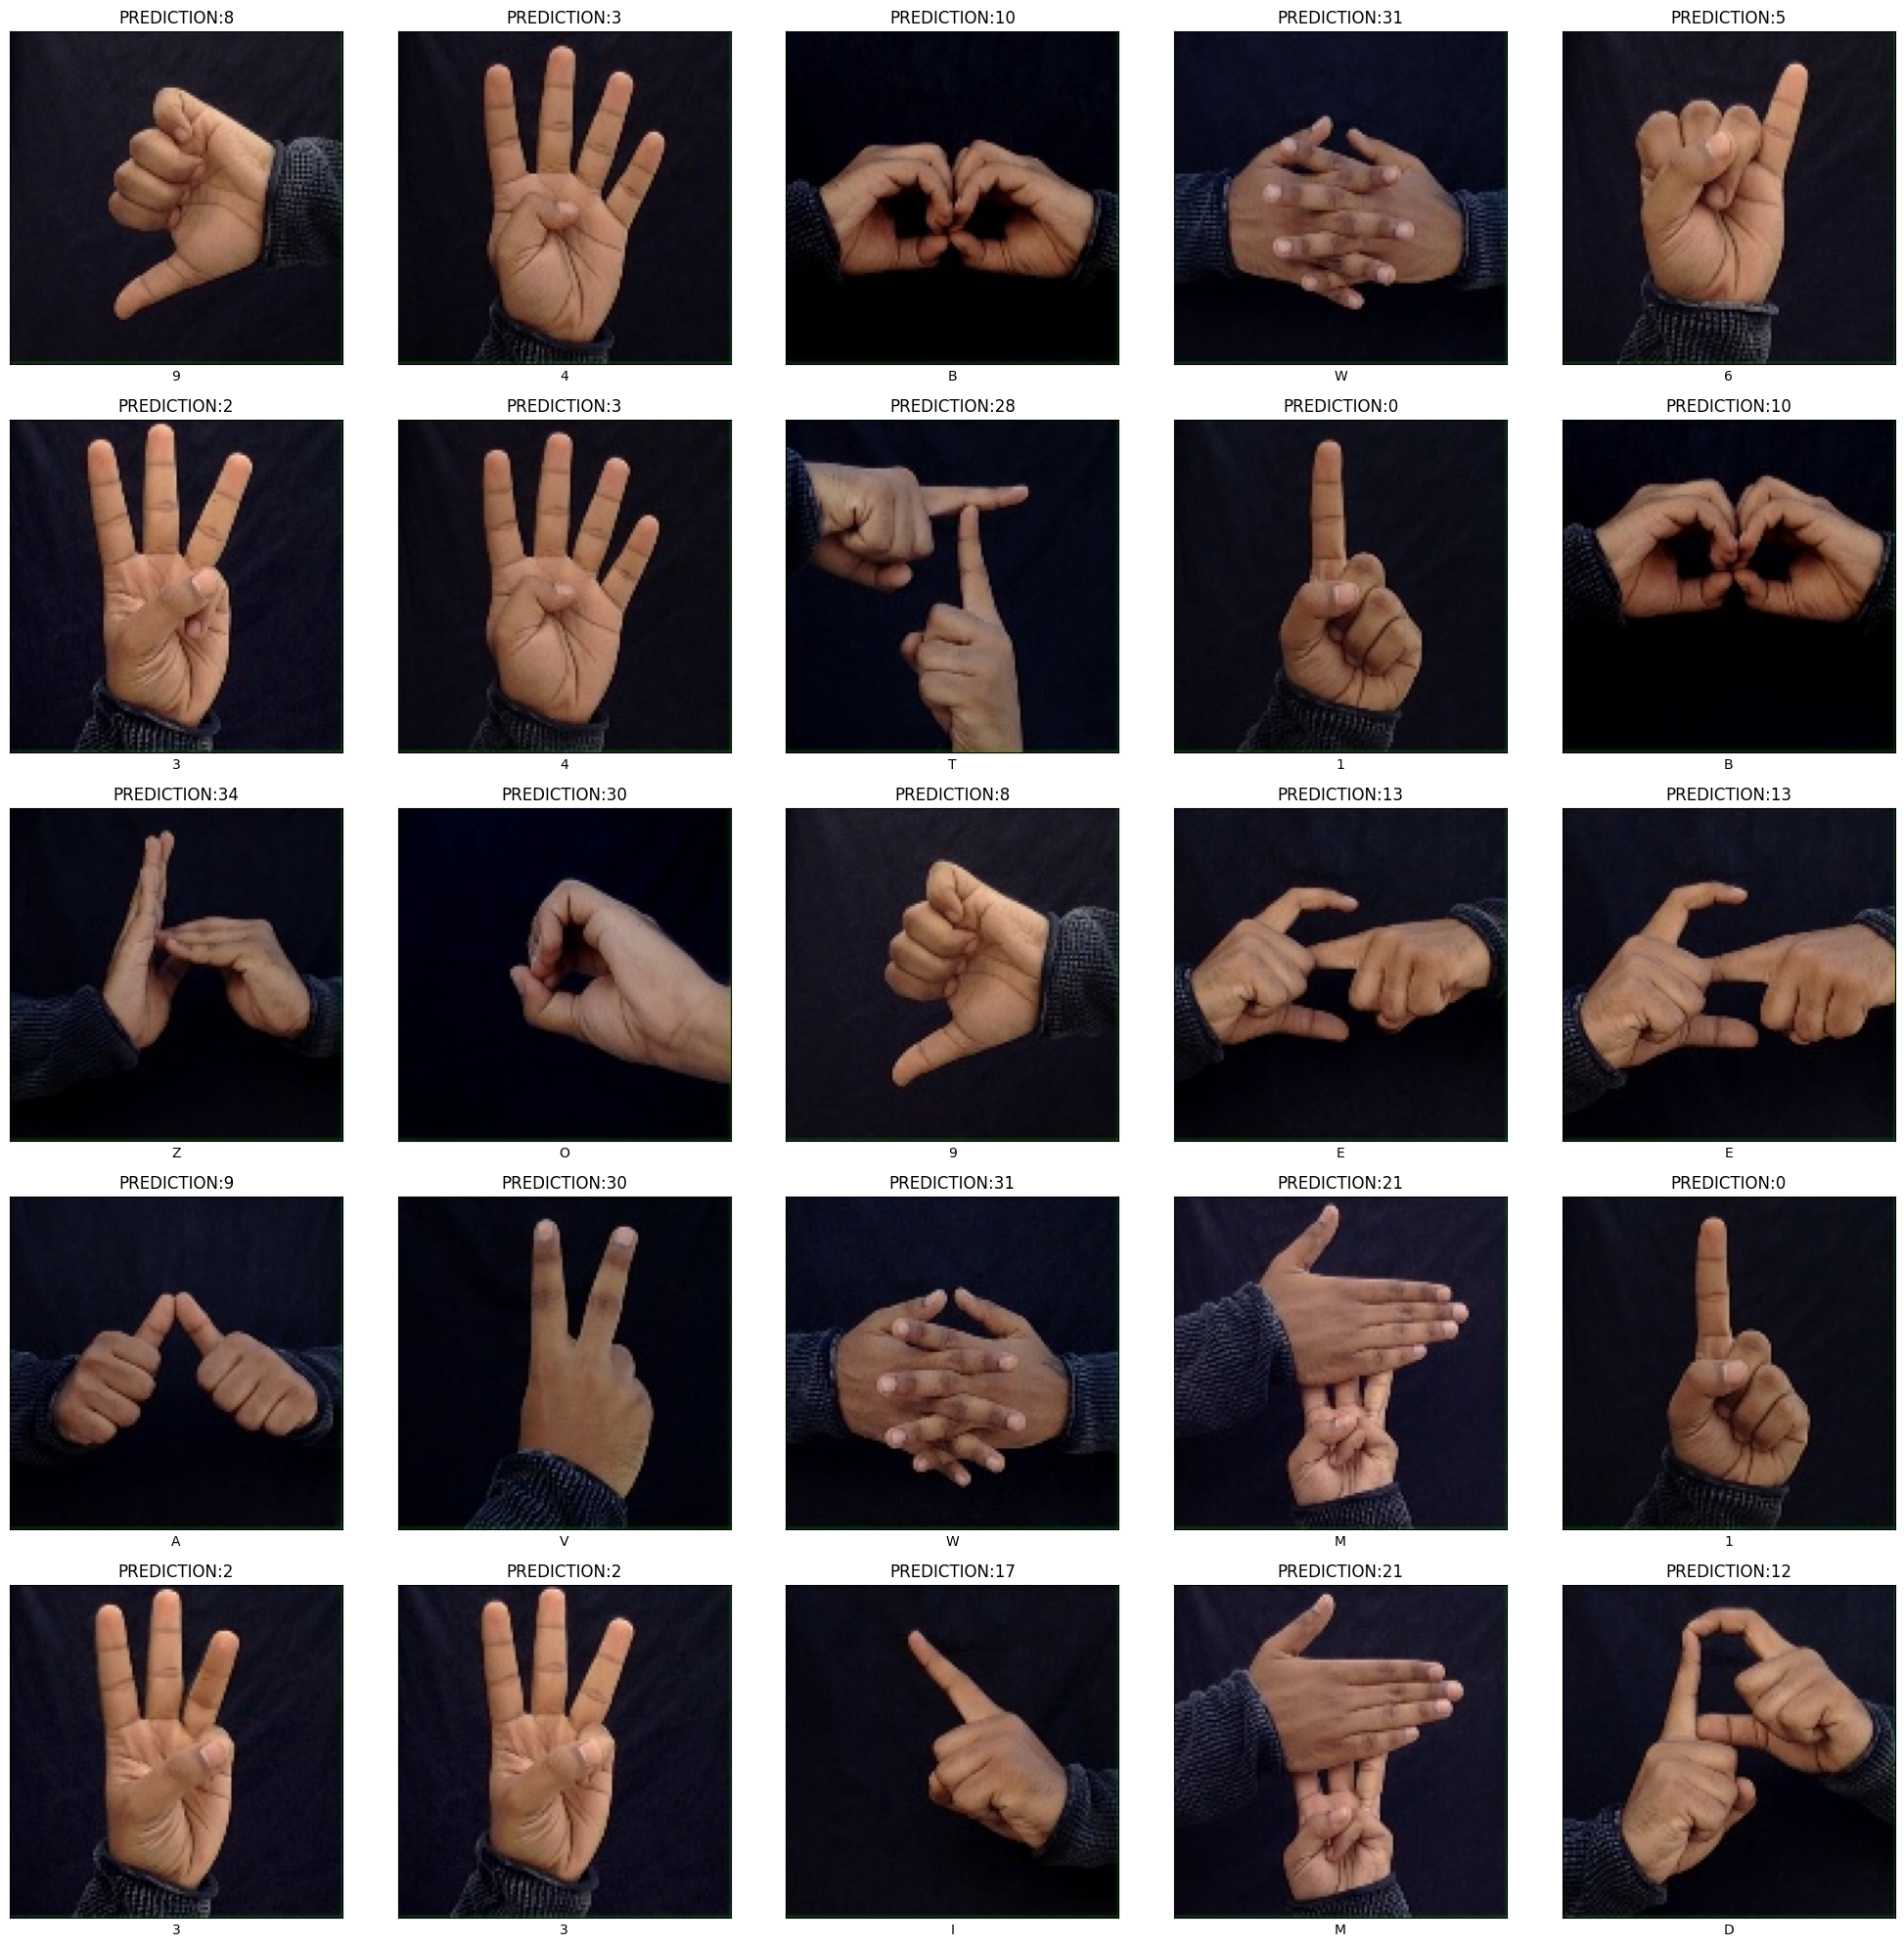

In [75]:
fig, axes = plt.subplots(nrows=5,
                         ncols=5,
                         figsize=(20, 20),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(X_Test["JPG"].iloc[i]))
    ax.set_title(f"PREDICTION:{Model_Test_Prediction[i]}")
    ax.set_xlabel(X_Test["CATEGORY"].iloc[i])
plt.tight_layout()
plt.show()